In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from scipy.optimize import least_squares
from scipy.special import spherical_jn as jn
import emcee
import os
from multiprocessing import Pool
import corner

import utils.lib.nn_studio as nn_studio
import utils.lib.chiral_potential as chiral_potential
import utils.lib.granada_phases as granada
import utils.lib.auxiliary as aux
import utils.lib.lec_values as lec_values
from utils.lib.constants import *

import time
import datetime

In [2]:
%matplotlib widget
plt.close('all')

# Inferenza Bayesiana NLO 

il codice che usiamo in generale è scritto con parti del corpo non adeguate cit. Milani

In [3]:
T_Lab = granada.Tlabs 

shift_1S0 = granada.delta_1S0
shift_1S0_error = granada.delta_1S0_errors

shift_3S1 = granada.delta_3S1
shift_3S1_error = granada.delta_3S1_errors

shift_3D1 = granada.delta_3D1
shift_3D1_error = granada.delta_3D1_errors

shift_mix = granada.delta_3E1
shift_mix_error = granada.delta_3E1_errors

In [4]:
nn = nn_studio.nn_studio(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=30, mesh_type="gauleg_infinite")
nn.Tlabs = T_Lab
nn.V = chiral_potential.two_nucleon_potential("NLO",Lambda=500.0)

_, channel_1S0 = nn.lookup_channel_idx(l=0,ll=0,s=0,j=0) 
_, channel_3S1 = nn.lookup_channel_idx(l=0,ll=2,s=1,j=1) 

In [5]:
# La generalizzazione di emcee sarà esattamente come ce la aspettiamo. Stavolta avremo 5 prior.

def ln_prior_NLO(parameters):
    C_1S0, C_3S1, D_1S0, D_3S1, D_mix = parameters
    
    avg_C1S0 = 0.0
    avg_C3S1 = 0.0
    avg_D1S0 = 0.0
    avg_D3S1 = 0.0
    avg_Dmix = 0.0
    sigma_C1S0 = 5.0
    sigma_C3S1 = 5.0
    sigma_D1S0 = 5.0
    sigma_D3S1 = 5.0
    sigma_Dmix = 5.0

    ln_C1S0 = -0.5 * ( np.log(2*np.pi * sigma_C1S0**2) + ((C_1S0-avg_C1S0) / sigma_C1S0)**2 )
    ln_C3S1 = -0.5 * ( np.log(2*np.pi * sigma_C3S1**2) + ((C_3S1-avg_C3S1) / sigma_C3S1)**2 )
    ln_D1S0 = -0.5 * ( np.log(2*np.pi * sigma_D1S0**2) + ((D_1S0-avg_D1S0) / sigma_D1S0)**2 )
    ln_D3S1 = -0.5 * ( np.log(2*np.pi * sigma_D3S1**2) + ((D_3S1-avg_D3S1) / sigma_D3S1)**2 )
    ln_Dmix = -0.5 * ( np.log(2*np.pi * sigma_Dmix**2) + ((D_mix-avg_Dmix) / sigma_Dmix)**2 )
    return ln_C1S0 + ln_C3S1 + ln_D1S0 + ln_D3S1 + ln_Dmix

def ln_likelihood_NLO(parameters, nnstudio, chn_1S0, exp_1S0, err_1S0, chn_3S1, exp_3S1, err_3S1, exp_3D1, err_3D1, exp_mix, err_mix):
    NLO_lecs = {}
    NLO_lecs["C_1S0"] = parameters[0]
    NLO_lecs["C_3S1"] = parameters[1]
    NLO_lecs["D_1S0"] = parameters[2]
    NLO_lecs["D_3S1"] = parameters[3]
    NLO_lecs["D_3S1-3D1"] = parameters[4]
    
    # Non abbiamo i dati sperimentali delle onde per i parametri rimanenti. Questo vuol dire che per essi prendiamo
    # dei valori nominali, e facciamo inferenza solo sui parametri che possiamo confrontare con gli esperimenti.
    NLO_lecs["D_1P1"] = 0.7
    NLO_lecs["D_3P0"] = 1.5
    NLO_lecs["D_3P1"] = -0.6
    NLO_lecs["D_3P2"] = -0.5
    nnstudio.lecs = NLO_lecs
    
    nnstudio.compute_Tmtx(chn_1S0, verbose=False)
    teo_1S0 = nnstudio.phase_shifts[0]
    nnstudio.compute_Tmtx(chn_3S1, verbose=False)
    teo_3S1 = nnstudio.phase_shifts[0][:,0]
    teo_mix = nnstudio.phase_shifts[0][:,1]
    teo_3D1 = nnstudio.phase_shifts[0][:,2]
    
    ln_L_1S0 = -0.5 * np.sum( np.log(2*np.pi * err_1S0**2) + ((exp_1S0-teo_1S0) / err_1S0)**2 )
    ln_L_3S1 = -0.5 * np.sum( np.log(2*np.pi * err_3S1**2) + ((exp_3S1-teo_3S1) / err_3S1)**2 )
    ln_L_mix = -0.5 * np.sum( np.log(2*np.pi * err_mix**2) + ((exp_mix-teo_mix) / err_mix)**2 )
    ln_L_3D1 = -0.5 * np.sum( np.log(2*np.pi * err_3D1**2) + ((exp_3D1-teo_3D1) / err_3D1)**2 )
    return ln_L_1S0 + ln_L_3S1 + ln_L_mix + ln_L_3D1

def ln_posterior_NLO(parameters, nnstudio, chn_1S0, exp_1S0, err_1S0, chn_3S1, exp_3S1, err_3S1, exp_3D1, err_3D1, exp_mix, err_mix):
    ln_post = ln_prior_NLO(parameters)
    ln_post += ln_likelihood_NLO(parameters, nnstudio, chn_1S0, exp_1S0, err_1S0, chn_3S1, exp_3S1, err_3S1, exp_3D1, err_3D1, exp_mix, err_mix)
    return ln_post 

In [6]:
# Metodo MCMC:
ndim = 5
nwalkers = 32
nsteps = 1000

initial_guess = [-0.10, -0.10, 1.0, -1.0, 0.1]
starting_positions = initial_guess + 1e-1 * np.random.randn(nwalkers, ndim)

ncpu = os.cpu_count()
if __name__ == "__main__":
    with Pool(processes=ncpu) as pool:
        sampler = emcee.EnsembleSampler(
            nwalkers, 
            ndim, 
            ln_posterior_NLO, 
            args=(nn, channel_1S0, shift_1S0, shift_1S0_error, channel_3S1, shift_3S1, shift_3S1_error, shift_3D1, shift_3D1_error, shift_mix, shift_mix_error),
            pool=pool
        )
        print(f"Eseguendo su {ncpu} core...")
        sampler.run_mcmc(starting_positions, nsteps, progress=True)
    print("\nFinito! :)")

Eseguendo su 12 core...


100%|██████████| 1000/1000 [5:36:41<00:00, 20.20s/it] 


Finito! :)


In [7]:
#tau = sampler.get_autocorr_time()

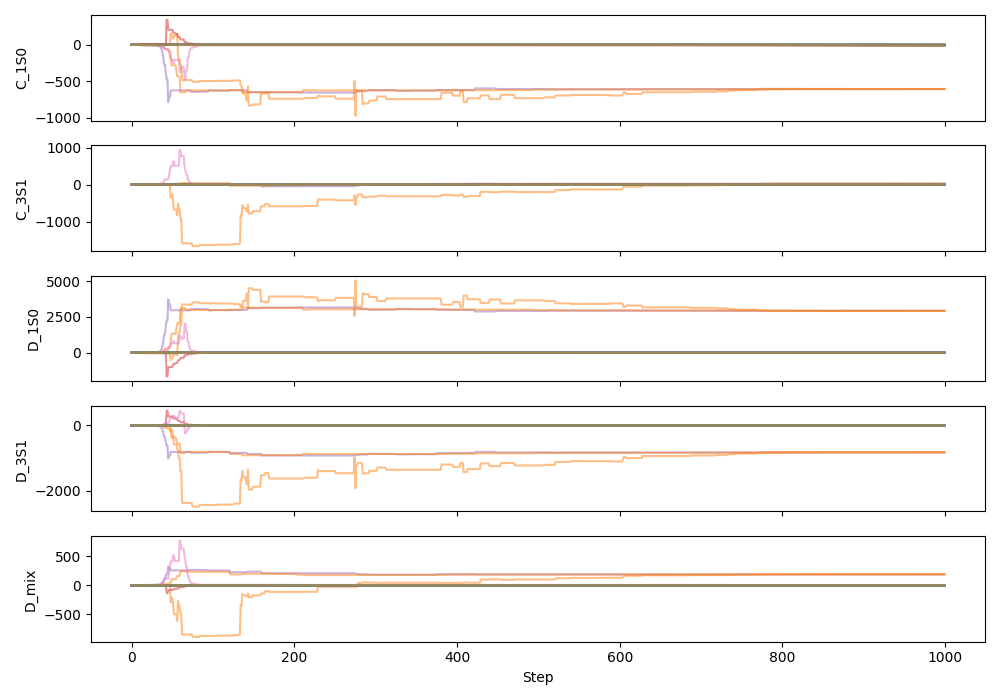

In [8]:
# traceplots
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
labels = ["C_1S0", "C_3S1", "D_1S0", "D_3S1", "D_mix"]
for i in range(ndim):
    ax = axes[i]
    for walker in range(nwalkers):
        ax.plot(sampler.chain[walker, :, i], alpha=0.5)
    ax.set_ylabel(labels[i])
axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()

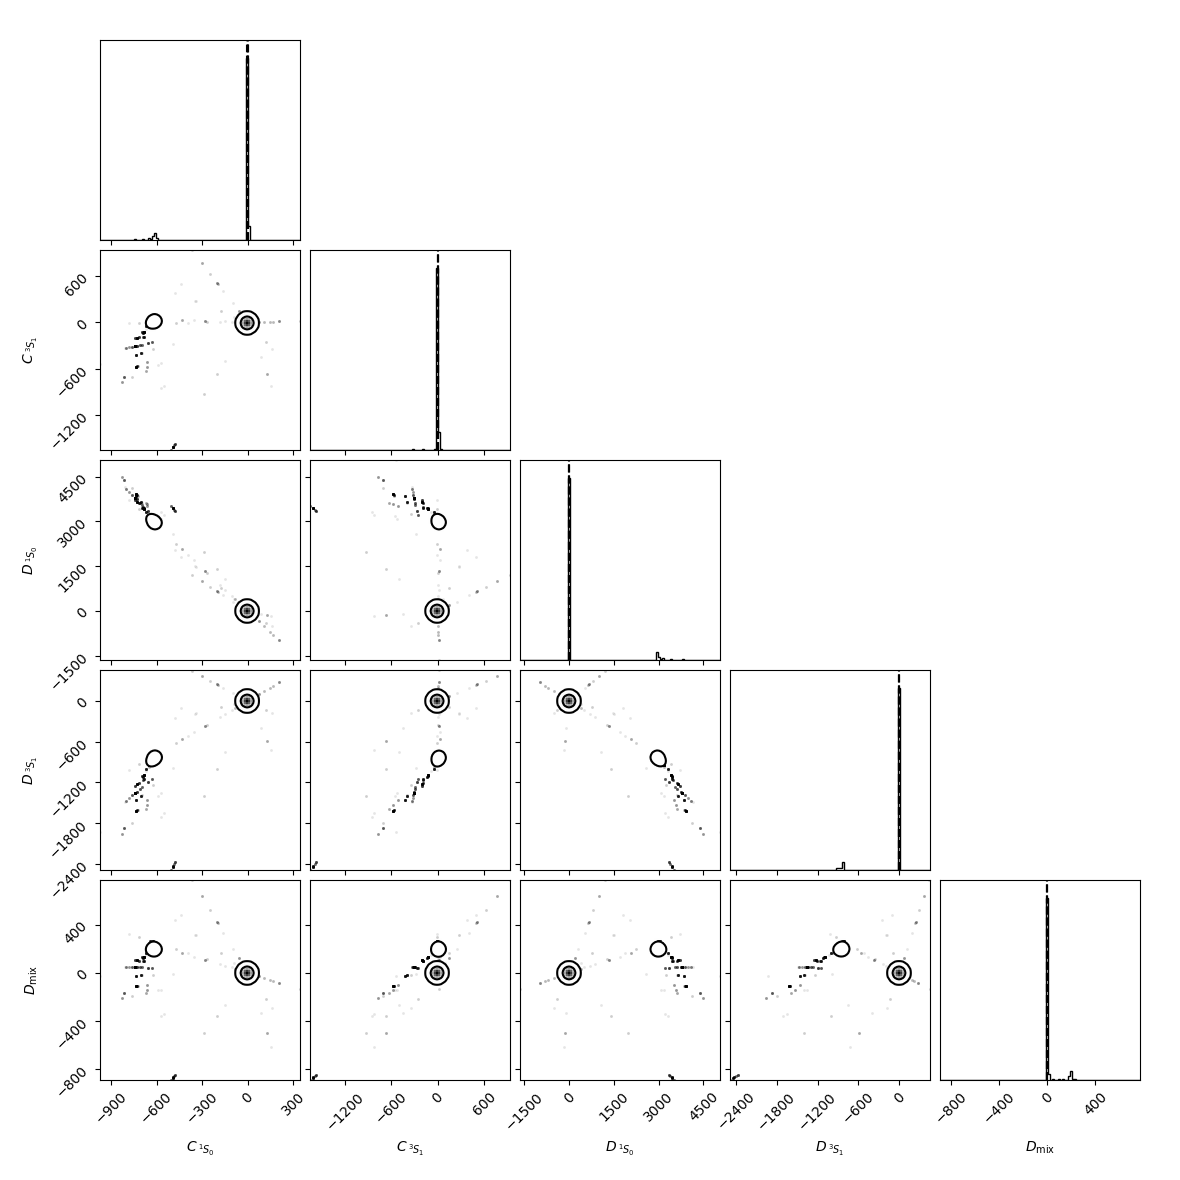

In [9]:
# Stampa dei corner plot:
flat_samples = sampler.get_chain(discard=int(0), thin=1, flat=True)

labels = [r"$C\,_{^1S_0}$", r"$C\,_{^3S_1}$", r"$D\,_{^1S_0}$", r"$D\,_{^3S_1}$", r"$D_{\mathrm{mix}}$"]
figure = corner.corner(
    flat_samples,
    labels=labels,
    show_titles=False,
    title_kwargs={"fontsize": 12},
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],
    plot_datapoints=True,
    bins=100,
    smooth=2.0,
    levels=(0.68, 0.95)
    #fill_contours=True,
    #color="royalblue"
)
plt.show()

In [10]:
# salvataggio campioni

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

all_samples = sampler.get_chain()
np.save(f"results/bayes_samples_NLO_full_{timestamp}.npy", all_samples)

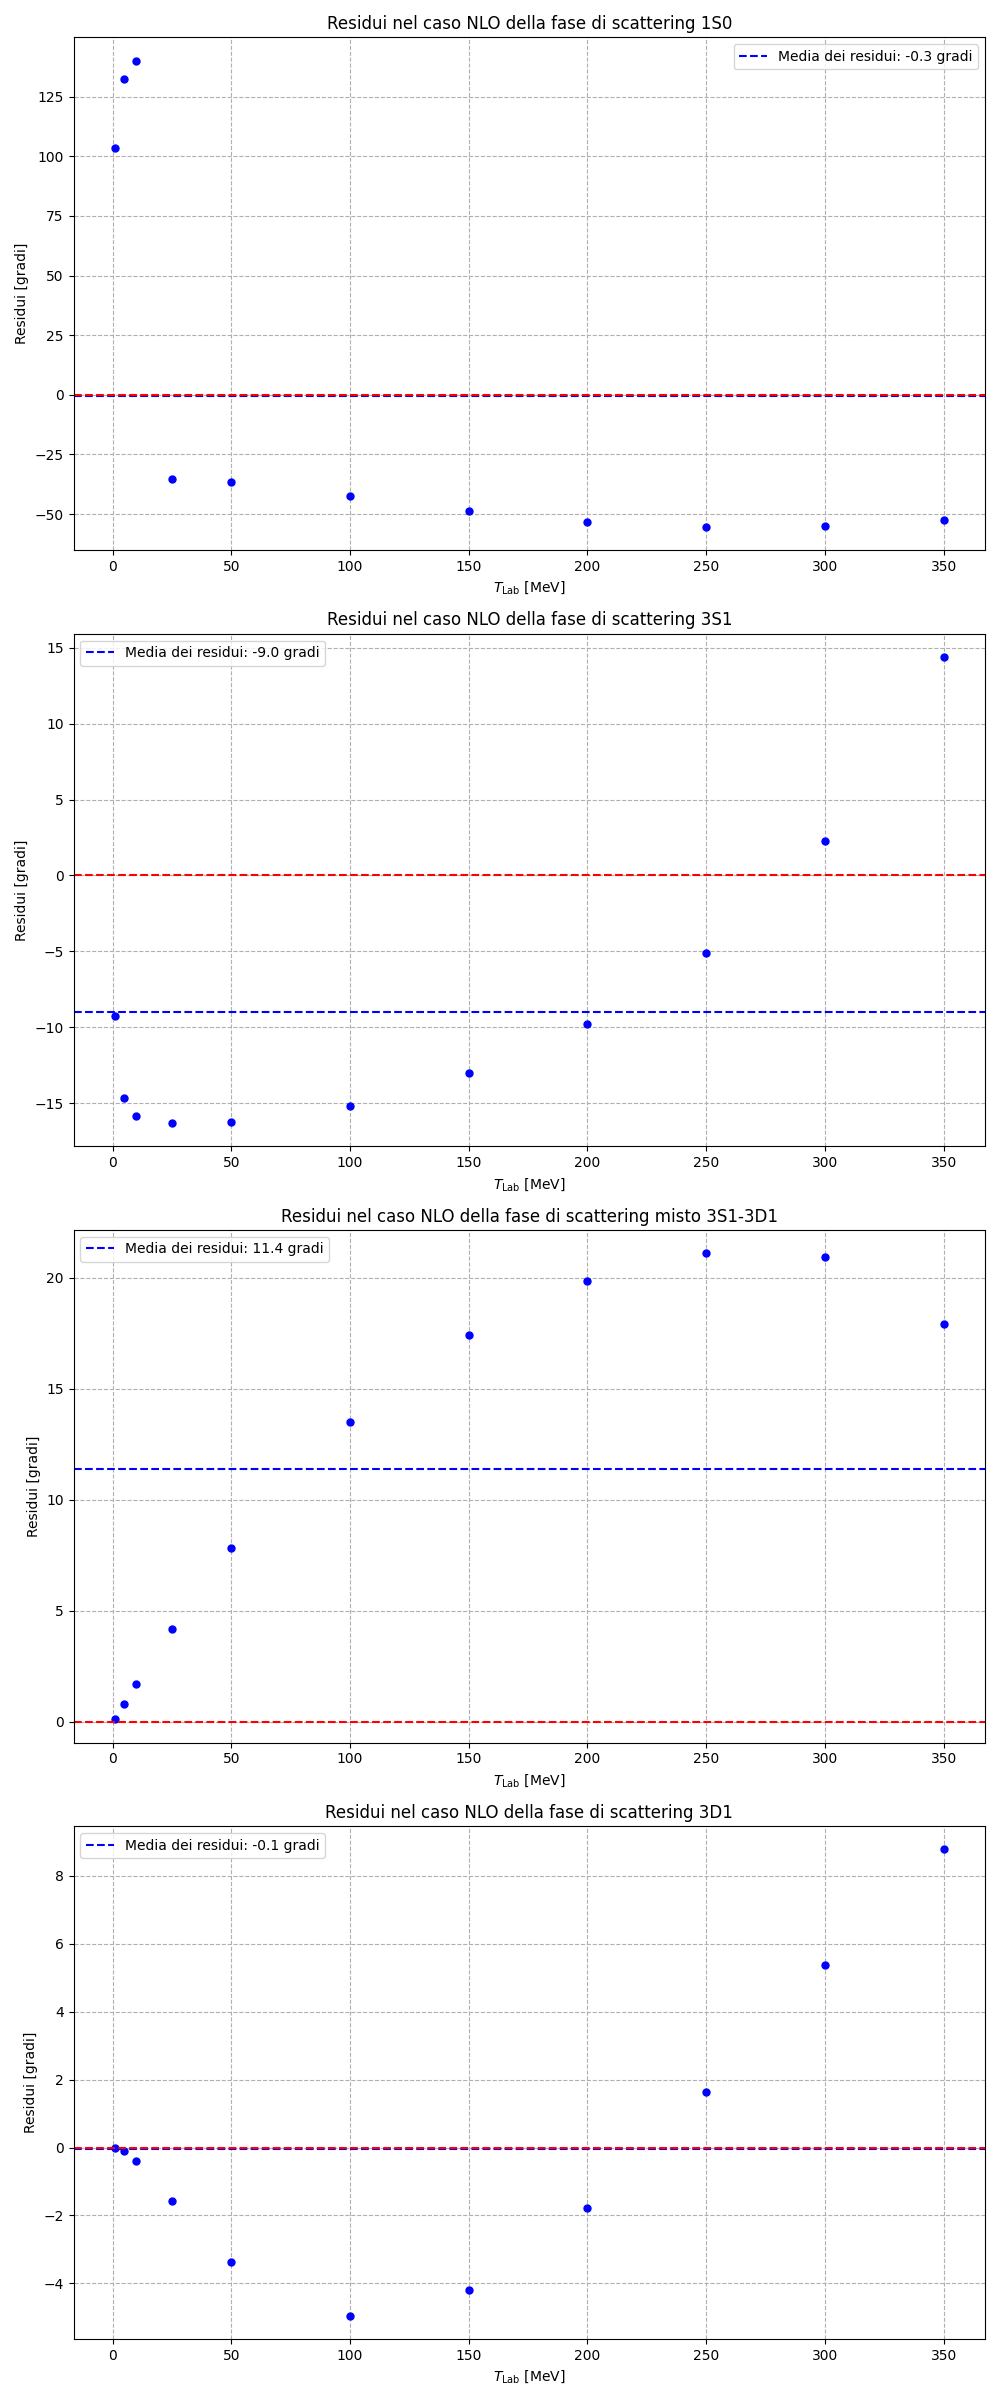

In [11]:
# Visualizzazione dei residui:
C_1S0_median = np.median(flat_samples[:, 0])
C_1S0_sigma = 0.5 * (np.percentile(flat_samples[:, 0], 84) - np.percentile(flat_samples[:, 0], 16))
C_3S1_median = np.median(flat_samples[:, 1])
C_3S1_sigma = 0.5 * (np.percentile(flat_samples[:, 1], 84) - np.percentile(flat_samples[:, 1], 16))
D_1S0_median = np.median(flat_samples[:, 2])
D_1S0_sigma = 0.5 * (np.percentile(flat_samples[:, 2], 84) - np.percentile(flat_samples[:, 2], 16))
D_3S1_median = np.median(flat_samples[:, 3])
D_3S1_sigma = 0.5 * (np.percentile(flat_samples[:, 3], 84) - np.percentile(flat_samples[:, 3], 16))
D_mix_median = np.median(flat_samples[:, 4])
D_mix_sigma = 0.5 * (np.percentile(flat_samples[:, 4], 84) - np.percentile(flat_samples[:, 4], 16))


nn.Tlabs = T_Lab
NLO_lecs = {}
NLO_lecs["C_1S0"] = C_1S0_median
NLO_lecs["C_3S1"] = C_3S1_median
NLO_lecs["D_1S0"] = D_1S0_median
NLO_lecs["D_3S1"] = D_3S1_median
NLO_lecs["D_3S1-3D1"] = D_mix_median
NLO_lecs["D_1P1"] = 0.7
NLO_lecs["D_3P0"] = 1.5
NLO_lecs["D_3P1"] = -0.6
NLO_lecs["D_3P2"] = -0.5
nn.lecs = NLO_lecs
nn.compute_Tmtx(channel_1S0, verbose=False)
teo_1S0 = nn.phase_shifts[0]
nn.compute_Tmtx(channel_3S1, verbose=False)
teo_3S1 = nn.phase_shifts[0][:,0]
teo_mix = nn.phase_shifts[0][:,1]
teo_3D1 = nn.phase_shifts[0][:,2]


residuals = []
residuals.append(shift_1S0 - teo_1S0)
residuals.append(shift_3S1 - teo_3S1)
residuals.append(shift_mix - teo_mix)
residuals.append(shift_3D1 - teo_3D1)
means_res = []
for i in range(len(residuals)):
    means_res.append(np.mean(residuals[i]))
titles = ["1S0", "3S1", "misto 3S1-3D1", "3D1"]

figure, axes = plt.subplots(4, figsize=(10, 24))
for i in range(4):
    inset = axes[i]
    inset.plot(T_Lab, residuals[i], marker = ".", linestyle = "None", color = "b", markersize = 10.)
    inset.axhline(means_res[i], linestyle= "--", color = "b", label=f"Media dei residui: {means_res[i]:.1f} gradi")
    inset.axhline(0, linestyle= "--", color = "r")
    inset.set_xlabel(r"$T_\mathrm{Lab}$ [MeV]")
    inset.set_ylabel(r"Residui [gradi]")
    inset.set_title(f"Residui nel caso NLO della fase di scattering {titles[i]}")
    inset.legend()
    inset.grid(linestyle = "--")
plt.tight_layout()
plt.show()